In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [1]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.83.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cach

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

In [11]:
df_churn = pd.read_csv(r"C:\Users\lohar\OneDrive\Documents\DA udemy\DS_ML_project\Churn_Modelling3.csv")

In [12]:
df_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Unnamed: 14,Unnamed: 15
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,NaN,NaN
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaN,NaN
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,NaN,NaN
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaN,NaN
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaN,NaN


In [13]:
df_churn.shape

(10000, 16)

In [14]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  Unnamed: 14      0 non-null      float64
 15  Unnamed: 15      0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory usage: 1.2+ MB


In [15]:
df_churn['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [16]:
df_churn['Exited'].value_counts(
    normalize=True
) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [17]:
X = df_churn.drop(
    ['Exited', 'RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

y = df_churn['Exited']

In [18]:
X.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Unnamed: 14        float64
Unnamed: 15        float64
dtype: object

In [19]:
X = pd.get_dummies(
    X,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [20]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Unnamed: 14,Unnamed: 15,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,NaN,NaN,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,NaN,NaN,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,NaN,NaN,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,NaN,NaN,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,NaN,NaN,False,True,False


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

Dense = tf.keras.layers.Dense
Sequential = tf.keras.Sequential
Input = tf.keras.Input

TensorFlow version: 2.21.0


In [26]:
print(Dense)
print(Sequential)

<class 'keras.src.layers.core.dense.Dense'>
<class 'keras.src.models.sequential.Sequential'>


In [27]:
model = Sequential([
    
    Input(shape=(X_train.shape[1],)),
    
    Dense(
        16,
        activation='relu'
    ),
    
    Dense(
        8,
        activation='relu'
    ),
    
    Dense(
        1,
        activation='sigmoid'
    )
])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
print("Model compiled successfully!")

Model compiled successfully!


In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7953 - loss: 0.6661 - val_accuracy: 0.8000 - val_loss: 0.6406
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7953 - loss: 0.6216 - val_accuracy: 0.8000 - val_loss: 0.6015
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.5880 - val_accuracy: 0.8000 - val_loss: 0.5720
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7953 - loss: 0.5632 - val_accuracy: 0.8000 - val_loss: 0.5502
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.5451 - val_accuracy: 0.8000 - val_loss: 0.5344
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.5323 - val_accuracy: 0.8000 - val_loss: 0.5231
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.5234 - val_accuracy: 0.8000 - val_loss: 0.5153
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.5173 - val_accuracy: 0.

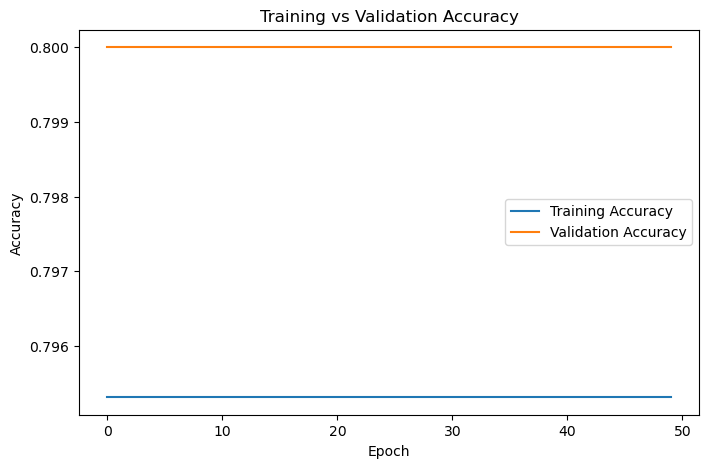

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title(
    'Training vs Validation Accuracy'
)

plt.legend()

plt.show()

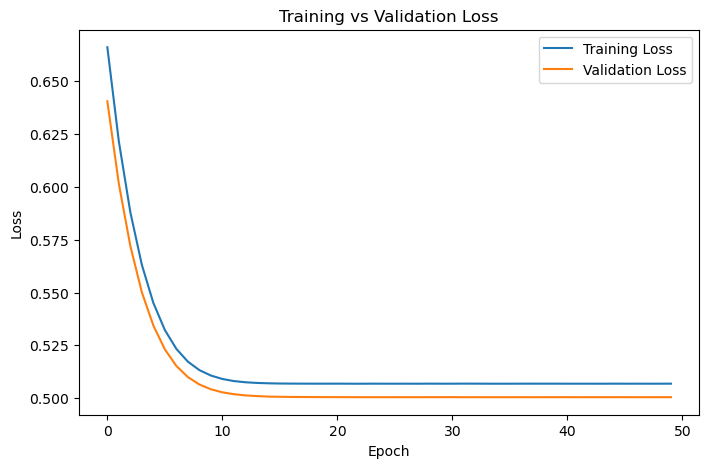

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training vs Validation Loss'
)

plt.legend()

plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

In [35]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.505221962928772
Test Accuracy: 0.796500027179718


In [36]:
probabilities = model.predict(
    X_test,
    verbose=0
)

In [37]:
probabilities[:10]

array([[0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267],
       [0.20486267]], dtype=float32)

In [38]:
predictions = (
    probabilities >= 0.5
).astype(int)

In [39]:
predictions[:10]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [40]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [41]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\lohar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lohar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lohar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[1593    0]
 [ 407    0]]


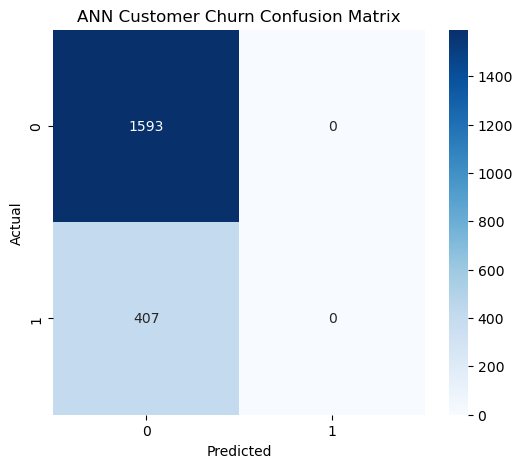

In [43]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title(
    'ANN Customer Churn Confusion Matrix'
)

plt.show()

In [44]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

auc = roc_auc_score(
    y_test,
    probabilities
)

C:\Users\lohar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.7965
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5


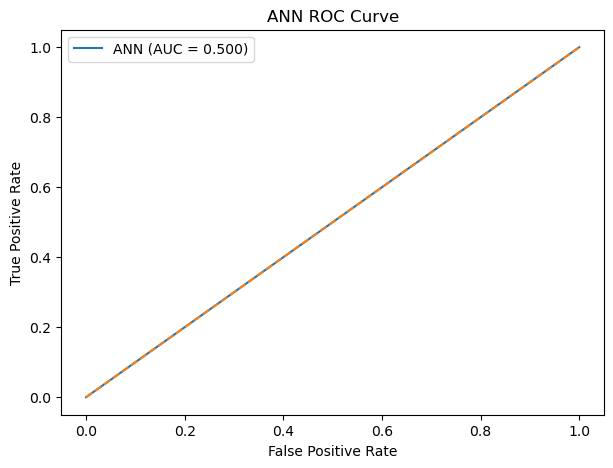

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ANN (AUC = {auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ANN ROC Curve')

plt.legend()

plt.show()

# ANN Project Conclusion

An Artificial Neural Network was developed to predict customer churn.

The workflow included:

- Data preprocessing
- Categorical encoding
- Train-test splitting
- Feature scaling
- ANN architecture design
- ReLU activation in hidden layers
- Sigmoid activation in the output layer
- Binary crossentropy loss
- Adam optimizer
- Model training using epochs and batches
- Validation monitoring
- Prediction using probability thresholds
- Confusion matrix
- Precision
- Recall
- F1-score
- ROC-AUC

The training and validation curves were analyzed to check for potential overfitting.